## The Unreasonable Effectiveness of Linear Regression

In [1]:
import numpy as np
import polars as pl

### Regresión Lineal y Ortogonalización en Inferencia Causal

En este capítulo añadirás la primera gran técnica de *des-biasing* a tu arsenal de inferencia causal: la **regresión lineal** u *ordinary least squares* (OLS) y la **ortogonalización**.

- **¿Por qué es importante la regresión lineal en causalidad?**  
    La regresión lineal permite ajustar por *confundidores* al estimar la relación entre un tratamiento ($T$) y un resultado ($Y$). Es decir, nos ayuda a aislar el efecto causal de $T$ sobre $Y$ controlando por variables que podrían sesgar la estimación.

- **Ortogonalización:**  
    Más allá de ajustar por confundidores, la ortogonalización es un concepto poderoso que surge de la regresión lineal. Consiste en "separar" el tratamiento de los confundidores, de modo que el efecto estimado sea puramente causal.

> Esta idea será fundamental cuando empieces a utilizar modelos de *machine learning* para inferencia causal, ya que permite generalizar el ajuste de confundidores más allá de los modelos lineales.

---



## Regression in A/B Tests

In [2]:
data = pl.read_csv("../data/rec_ab_test.csv")
data

recommender,age,tenure,watch_time
str,i64,i64,f64
"""challenger""",15,1,2.39
"""challenger""",27,1,2.32
"""benchmark""",17,0,2.74
"""benchmark""",34,1,1.92
"""benchmark""",14,1,2.47
…,…,…,…
"""benchmark""",18,0,2.13
"""benchmark""",16,0,1.7
"""benchmark""",15,0,1.25


- **En un A/B test aleatorizado**, comparar la media de los grupos (challenger vs. control) estima directamente el ATE (Average Treatment Effect).
- **Modelo de regresión lineal simple:**  
    $$
    \text{WatchTime}_i = \beta_0 + \beta_1 \cdot \text{challenger}_i + e_i
    $$
    - $\text{challenger}_i$: 1 si el usuario recibió la nueva versión, 0 si no.
    - $\beta_0$: media del grupo control.
    - $\beta_1$: diferencia de medias (ATE).
- **Ventajas de la regresión:**
    - $\beta_1$ estima el efecto causal del tratamiento.
    - Proporciona error estándar, intervalo de confianza y p-valor para $\beta_1$.
    - Si la asignación es aleatoria, no necesitas ajustar por confundidores: regresión y diferencia de medias son equivalentes.
- **Conclusión:**  
    La regresión lineal en A/B tests aleatorizados es una forma eficiente de obtener el ATE y toda la inferencia estadística asociada.


In [3]:
import statsmodels.formula.api as smf

# Ajustamos el modelo de regresión lineal
result = smf.ols('watch_time ~ C(recommender)', data=data.to_pandas()).fit()

# Mostramos la tabla de coeficientes
result.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,2.0491,0.058,35.367,0.000,1.935,2.163
C(recommender)[T.challenger],0.1427,0.095,1.501,0.134,-0.044,0.330


In [4]:
data.filter(pl.col("recommender") == 'benchmark').select(pl.col("watch_time").mean())

watch_time
f64
2.049064


In [5]:
(
    data.group_by("recommender")
        .agg(pl.col("watch_time").mean().alias("mean_watch_time"))
)

recommender,mean_watch_time
str,f64
"""challenger""",2.19175
"""benchmark""",2.049064


## Notas clave sobre regresión en A/B tests
- **Intercepto ($\beta_0$):** Es la media de `watch_time` para el grupo benchmark (recomendador antiguo).
- **Coeficiente challenger ($\beta_1$):** Es la diferencia de medias entre challenger y benchmark. Si es positivo, el nuevo recomendador aumenta el tiempo de visualización.
- **Interpretación causal:** Gracias a la aleatorización, $\beta_1$ estima el efecto causal promedio (ATE) de cambiar al nuevo recomendador.
- **Cálculo de medias:**
    - Grupo benchmark: $\beta_0$
    - Grupo challenger: $\beta_0 + \beta_1$
- **Significancia estadística:** Si el intervalo de confianza de $\beta_1$ incluye el cero, el efecto no es estadísticamente significativo.
- **Ventaja de la regresión:** Obtienes el ATE, su error estándar, intervalo de confianza y p-valor en un solo paso.
- **¡Ojo!** En estudios observacionales, necesitas ajustar por confundidores para que la interpretación causal sea válida.

## Adjusting with Regression

In [6]:
risk_data = pl.read_csv("../data/risk_data.csv")
risk_data

wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
f64,i64,i64,i64,f64,f64,f64,i64
950.0,11,16,1,500.0,518.0,3200.0,0
780.0,11,7,1,414.0,429.0,1700.0,0
1230.0,14,9,1,586.0,571.0,4200.0,0
1040.0,15,8,1,379.0,411.0,1500.0,0
1000.0,16,1,1,379.0,518.0,1800.0,0
…,…,…,…,…,…,…,…
840.0,12,13,1,466.0,482.0,2400.0,0
700.0,15,16,1,328.0,393.0,1100.0,0
930.0,14,16,1,552.0,339.0,1700.0,0


In [7]:
risk_data.describe()

statistic,wage,educ,exper,married,credit_score1,credit_score2,credit_limit,default
str,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0,50000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",1061.518,13.48886,11.55078,0.89612,471.10254,487.86192,2848.57,0.1508
"""std""",412.304605,2.20769,4.36497,0.305108,113.401589,117.063919,1372.623633,0.357857
"""min""",120.0,9.0,1.0,0.0,34.0,36.0,200.0,0.0
"""25%""",770.0,12.0,8.0,1.0,397.0,411.0,1900.0,0.0
"""50%""",1010.0,12.0,11.0,1.0,466.0,482.0,2700.0,0.0
"""75%""",1270.0,16.0,15.0,1.0,534.0,571.0,3700.0,0.0
"""max""",3310.0,18.0,23.0,1.0,1034.0,1036.0,8500.0,1.0


### Contexto: Efecto del Límite de Crédito sobre el Default

- **Tratamiento ($T$):**  
    $credit\_limit$ (límite de crédito, variable continua)

- **Resultado ($Y$):**  
    $default$ (variable binaria: 1 si el cliente incumplió, 0 si no)

- **Confundidores ($X$):**  
    $wage$ (salario), $educ$ (años de educación), $exper$ (años de experiencia), $married$ (estado civil), $credit\_score1$, $credit\_score2$, etc.

---

**Pregunta causal:**  
> ¿Cuál es el efecto causal de aumentar el límite de crédito ($T$) sobre la probabilidad de default ($Y$), ajustando por los posibles confundidores ($X$)?

$$
Y = f(T, X) \\
\text{Queremos estimar: } E[Y \mid do(T = t)]
$$


In [8]:
model = smf.ols("default ~ credit_limit", data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.2192,0.004,59.715,0.000,0.212,0.226
credit_limit,-2.402e-05,1.16e-06,-20.689,0.000,-2.63e-05,-2.17e-05


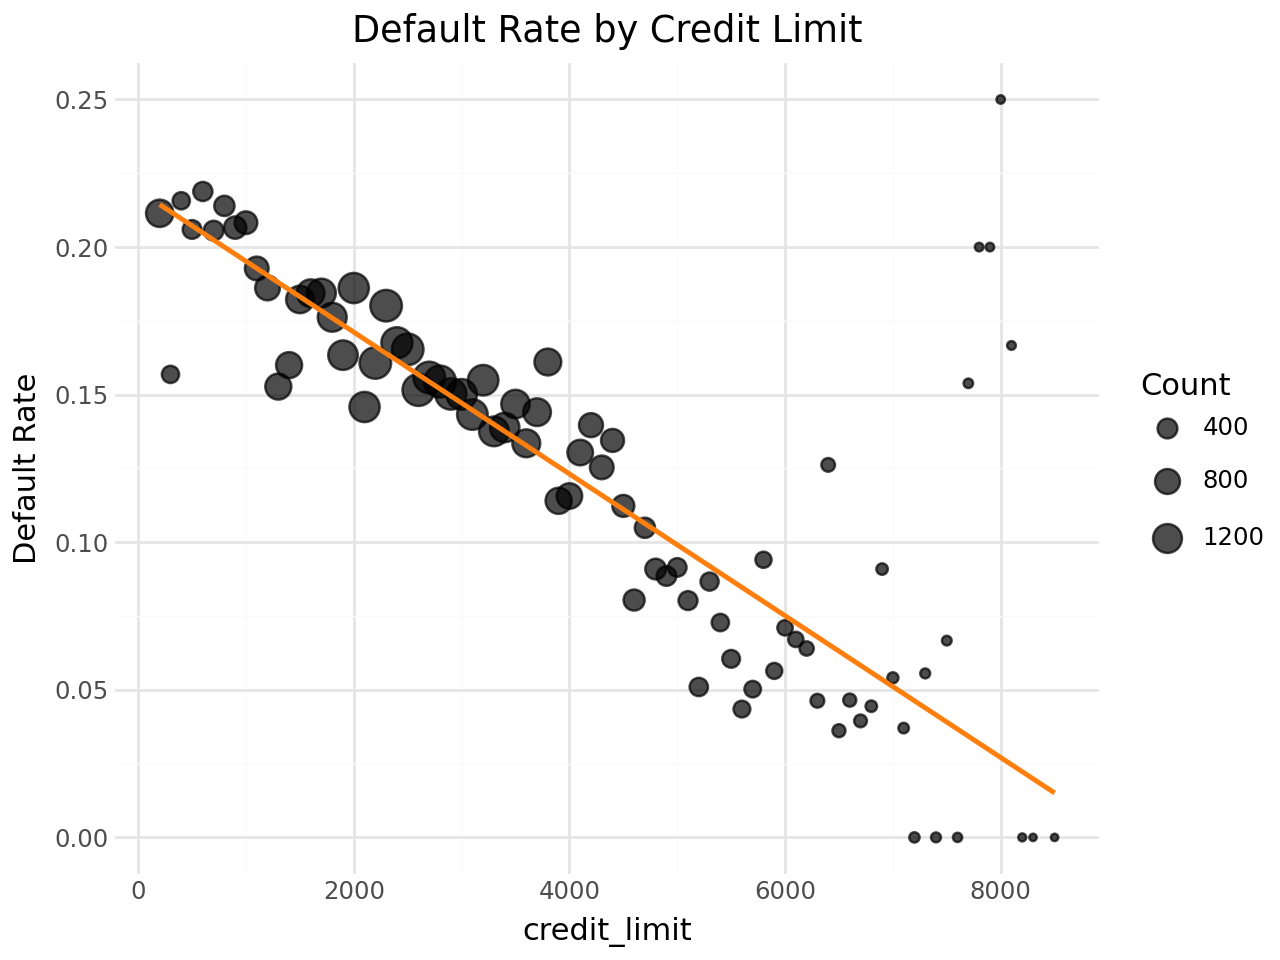

In [9]:
import polars as pl
from plotnine import *

plt_df = (
    risk_data
    .group_by("credit_limit")
    .agg([
        pl.col("default").mean(),       # Calcula el promedio de default
        pl.len().alias("size")          # Cuenta las filas (equivalente a sum size)
    ])
    .sort("credit_limit")               # Ordenamos para que la línea del gráfico salga bien
)

preds = model.predict(plt_df.to_pandas())

# Añadimos la columna de predicción al DataFrame de Polars
plt_df = plt_df.with_columns(
    prediction = pl.Series(preds)
)

(
    ggplot(plt_df, aes(x="credit_limit")) +
    
    # Capa 1: Los puntos (sns.scatterplot)
    # Mapeamos 'size' al tamaño para tener las burbujas
    geom_point(aes(y="default", size="size"), alpha=0.7) +
    
    # Capa 2: La línea de predicción (plt.plot)
    # Usamos la columna 'prediction' que calculaste
    geom_line(aes(y="prediction"), color="#ff7f0e", size=1) + # color C1 es naranja aprox
    
    # Ajustes visuales para que se vea igual
    labs(
        title="Default Rate by Credit Limit",
        y="Default Rate",
        size="Count" # Etiqueta de la leyenda de tamaño
    ) +
    theme_minimal()
)

In [10]:
(
    risk_data.group_by(["credit_score1", "credit_score2"])
             .len()
             .sort("credit_score1")
             .head(10)
)

credit_score1,credit_score2,len
f64,f64,u32
34.0,500.0,1
34.0,339.0,1
52.0,518.0,1
69.0,357.0,1
69.0,393.0,1
69.0,214.0,1
86.0,446.0,1
103.0,321.0,2
103.0,250.0,1


In [12]:
formula = "default ~ credit_limit + wage + credit_score1 + credit_score2"
model = smf.ols(formula, data=risk_data.to_pandas()).fit()
model.summary().tables[1]

,coef,std err,t,P>|t|,[0.025,0.975]
Intercept,0.4037,0.009,46.939,0.000,0.387,0.421
credit_limit,3.063e-06,1.54e-06,1.987,0.047,4.16e-08,6.08e-06
wage,-8.822e-05,6.07e-06,-14.541,0.000,-0.000,-7.63e-05
credit_score1,-4.175e-05,1.83e-05,-2.278,0.023,-7.77e-05,-5.82e-06
credit_score2,-0.0003,1.52e-05,-20.055,0.000,-0.000,-0.000


In [14]:
import statsmodels.api as sm
X = risk_data[['wage','credit_score1','credit_score2']].to_pandas()
X = sm.add_constant(X)
res_t = sm.OLS(risk_data['credit_limit'], X).fit()
r_t = res_t.resid
res_y = sm.OLS(risk_data['default'], X).fit()
r_y = res_y.resid
beta1 = sm.OLS(r_y, r_t).fit().params[0]
print('beta1 (FWL):', beta1)

beta1 (FWL): 3.062527732125304e-06


C:\Users\sergi\AppData\Local\Temp\ipykernel_12012\2620109530.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


## Explicación Paso a Paso del Teorema Frisch-Waugh-Lovell (FWL)

El **Teorema FWL** es una herramienta poderosa en regresión lineal que permite separar el efecto de interés (del tratamiento) de los efectos de los confundidores. Básicamente, demuestra que el coeficiente de una variable en una regresión múltiple es igual al coeficiente obtenido al regredir los residuos de ambas variables sobre los residuos de los confundidores.

**Intuición:**  
FWL permite "limpiar" el tratamiento y el outcome de la influencia de los confundidores, y luego estimar el efecto causal usando solo la variación "ortogonal" (independiente) de los confundidores.

**Pasos del algoritmo FWL:**
1. Seleccionar las variables confundidoras (X).
2. Regresar el tratamiento (T) sobre X y obtener los residuos (r_T).
3. Regresar el outcome (Y) sobre X y obtener los residuos (r_Y).
4. Regresar r_Y sobre r_T para obtener β₁ (el efecto causal ajustado).

**Ventajas:**
- Separa el "des-biasing" del análisis final.
- Permite reutilizar el tratamiento residualizado para múltiples outcomes sin recalcular X.
- Es la base de técnicas modernas como Double Machine Learning (DML).

In [15]:
# Paso 1: Seleccionar las variables confundidoras (X) y añadir constante
# X son las variables que queremos mantener fijas al estimar el efecto causal
X = risk_data[['wage', 'credit_score1', 'credit_score2']].to_pandas()
X = sm.add_constant(X)  # Añade la columna de intercepto (constante) para la regresión
print("Matriz X (primeras 5 filas):")
X.head()

Matriz X (primeras 5 filas):


,const,wage,credit_score1,credit_score2
0,1.0,950.0,500.0,518.0
1,1.0,780.0,414.0,429.0
2,1.0,1230.0,586.0,571.0
3,1.0,1040.0,379.0,411.0
4,1.0,1000.0,379.0,518.0


In [16]:
# Paso 2: Regresar el tratamiento (T) sobre X y obtener residuos (r_T)
# Esto captura la parte del tratamiento explicada por los confundidores
res_t = sm.OLS(risk_data['credit_limit'], X).fit()
r_t = res_t.resid  # Residuos: variación en T no explicada por X
print("Residuos de T (r_T) - primeros 5 valores:")
print(r_t.head())
print(f"R² de la regresión T ~ X: {res_t.rsquared:.4f}")  # Qué porcentaje de T explica X

Residuos de T (r_T) - primeros 5 valores:
0     499.013906
1    -517.483433
2     816.564174
3   -1127.636740
4    -763.910173
dtype: float64
R² de la regresión T ~ X: 0.4448


In [17]:
# Paso 3: Regresar el outcome (Y) sobre X y obtener residuos (r_Y)
# Esto captura la parte del outcome explicada por los confundidores
res_y = sm.OLS(risk_data['default'], X).fit()
r_y = res_y.resid  # Residuos: variación en Y no explicada por X
print("Residuos de Y (r_Y) - primeros 5 valores:")
print(r_y.head())
print(f"R² de la regresión Y ~ X: {res_y.rsquared:.4f}")  # Qué porcentaje de Y explica X

Residuos de Y (r_Y) - primeros 5 valores:
0   -0.149819
1   -0.193975
2   -0.107511
3   -0.179227
4   -0.150040
dtype: float64
R² de la regresión Y ~ X: 0.0298


In [18]:
# Paso 4: Regresar los residuos de Y sobre los residuos de T
# Esto da el coeficiente causal β₁, ajustado por X
fwl_model = sm.OLS(r_y, r_t).fit()
beta1_fwl = fwl_model.params[0]
print(f"β₁ estimado por FWL: {beta1_fwl}")
print(f"Error estándar: {fwl_model.bse[0]}")
print(f"p-valor: {fwl_model.pvalues[0]}")
print(f"Intervalo de confianza 95%: {fwl_model.conf_int().iloc[0].values}")

β₁ estimado por FWL: 3.062527732125304e-06
Error estándar: 1.5412183880389336e-06
p-valor: 0.04691872836973873
Intervalo de confianza 95%: [4.17220723e-08 6.08333339e-06]


C:\Users\sergi\AppData\Local\Temp\ipykernel_12012\4271264799.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\sergi\AppData\Local\Temp\ipykernel_12012\4271264799.py:6: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
C:\Users\sergi\AppData\Local\Temp\ipykernel_12012\4271264799.py:7: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`


In [19]:
# Comparación: β₁ de la regresión completa vs FWL
# Regresión completa: Y ~ T + X
full_model = sm.OLS(risk_data['default'], sm.add_constant(risk_data[['credit_limit', 'wage', 'credit_score1', 'credit_score2']].to_pandas())).fit()
beta1_full = full_model.params['credit_limit']
print(f"β₁ de regresión completa: {beta1_full}")
print(f"β₁ de FWL: {beta1_fwl}")
print(f"Diferencia: {abs(beta1_full - beta1_fwl)}")  # Debería ser prácticamente cero

β₁ de regresión completa: 3.0625277321251984e-06
β₁ de FWL: 3.062527732125304e-06
Diferencia: 1.0545560193316039e-19


## ¿Por qué FWL simplifica OLS y es útil en inferencia causal?

**Equivalencia algebraica:**  
FWL demuestra que el coeficiente de `credit_limit` en la regresión completa `default ~ credit_limit + wage + credit_score1 + credit_score2` es **exactamente igual** al coeficiente obtenido al regredir los residuos `r_y ~ r_t`. Esto es una identidad matemática bajo OLS.

**Simplificación conceptual:**  
- **Separa el "des-biasing" del análisis:** Primero "limpias" el tratamiento y el outcome de los confundidores (pasos 1-3), luego estimas el efecto causal (paso 4).
- **Reutilización:** Si tienes múltiples outcomes, solo calculas `r_t` una vez y luego regresas cada `r_y` sobre `r_t`. No necesitas recalcular los efectos de X cada vez.
- **Interpretación clara:** `r_t` es la variación en el tratamiento que no está correlacionada con X. `r_y` es la variación en el outcome que no está correlacionada con X. Al relacionarlos, obtienes el efecto causal "puro".

**Ventajas prácticas en causalidad:**  
- **Preprocesamiento:** Permite "des-biasear" el tratamiento una vez y compartirlo con otros analistas sin que conozcan los confundidores.
- **Base de métodos avanzados:** FWL es fundamental para técnicas como Double Machine Learning (DML), donde usas ML para estimar los residuos en lugar de OLS.
- **Robustez:** Si X está bien especificado, FWL elimina el sesgo por confundidores observados, permitiendo una interpretación causal más confiable.

**Nota importante:** FWL asume linealidad y OLS. Si el modelo es no lineal, la equivalencia no se mantiene exactamente. Además, no elimina sesgo por variables no observadas.